# HDBSCAN Clustering

Applied to mound centroids in the Isaura parcel at three cluster-size scales: `min_cluster_size` = 4, 10, 20. `min_samples` = 4 throughout, consistent with DBSCAN, controlling how conservative the core-point density estimate is (Campello et al. 2013).

In [15]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import hdbscan
from sklearn.neighbors import BallTree
from scipy.spatial import ConvexHull
import warnings
warnings.filterwarnings('ignore')

# If hdbscan is not installed:
# conda install -c conda-forge hdbscan

print('imports done')

imports done


## 1. Load data

In [16]:
features = gpd.read_file("/Users/amber/Documents/M Thesis/Data/QGIS/isaura_features.gpkg")
parcel   = gpd.read_file("/Users/amber/Documents/M Thesis/Data/QGIS/08_isaura_extent_parcels.gpkg")
mounds   = features[features['type'] == 'mound'].copy()

print(f"Mound features: {len(mounds)}")
print(f"CRS: {mounds.crs}")

Mound features: 2671
CRS: EPSG:32644


## 2. Extract centroids

In [17]:
centroids = mounds.geometry.centroid
x = centroids.x.values
y = centroids.y.values
coords = np.column_stack([x, y])

print(f"n = {len(coords)}")
print(f"X range: {x.min():.0f} -- {x.max():.0f} m")
print(f"Y range: {y.min():.0f} -- {y.max():.0f} m")

n = 2671
X range: 364 -- 21385 m
Y range: -5 -- 15656 m


---
## 3. Parameter selection - min_cluster_size

HDBSCAN does not require a global epsilon. Instead, `min_cluster_size` controls the coarseness of the result: the smallest group of points that can constitute a cluster. Three values are tested here, spanning fine- to coarse-grained settlement structure:

| `min_cluster_size` | Rationale |
|---|---|
| 4 | Exploratory lower bound; matches DBSCAN `min_samples` for direct comparison |
| 10 | Medium scale; captures individual site epicentral cores (Golden et al. 2021) |
| 20 | Coarse scale; delineates major settlement agglomerations and peri-urban zones (Golden et al. 2021) |

`min_samples` = 4 throughout (Campello et al. 2013; consistent with DBSCAN comparison). `cluster_selection_method` = `'eom'` (excess of mass; default), which extracts flat, non-overlapping clusters from the hierarchy.

In [18]:
# Nearest-neighbour distances for spatial context
tree = BallTree(coords, metric='euclidean')
d2, _ = tree.query(coords, k=2)
mean_nnd = d2[:, 1].mean()

print(f"Mean NND:  {mean_nnd:.1f} m")
print(f"3x NND:    {3*mean_nnd:.0f} m")
print()
print("min_cluster_size values: 4, 10, 20  (following Golden et al. 2021)")
print("min_samples = 4 (consistent with DBSCAN)")

Mean NND:  120.1 m
3x NND:    360 m

min_cluster_size values: 4, 10, 20  (following Golden et al. 2021)
min_samples = 4 (consistent with DBSCAN)


---
## 4. Run HDBSCAN - three scales

`prediction_data=True` is set to enable membership probabilities in section 9.

In [19]:
MIN_SAMPLES = 4
MCS_VALUES  = [4, 10, 20]
MCS_LABELS  = {
    4:  'min_cluster_size = 4   (fine)',
    10: 'min_cluster_size = 10  (medium)',
    20: 'min_cluster_size = 20  (coarse)',
}

clusterers = {}
results    = {}

for mcs in MCS_VALUES:
    cl     = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=MIN_SAMPLES,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )
    labels = cl.fit_predict(coords)
    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    n_no   = (labels == -1).sum()
    clusterers[mcs] = cl
    results[mcs]    = labels
    print(f"mcs = {mcs:>2} | clusters: {n_cl:>4} | noise: {n_no:>5} ({100*n_no/len(labels):.1f}%)")

mcs =  4 | clusters:  112 | noise:  1021 (38.2%)
mcs = 10 | clusters:   55 | noise:  1112 (41.6%)
mcs = 20 | clusters:   28 | noise:  1251 (46.8%)


---
## 5. Cluster maps - individual

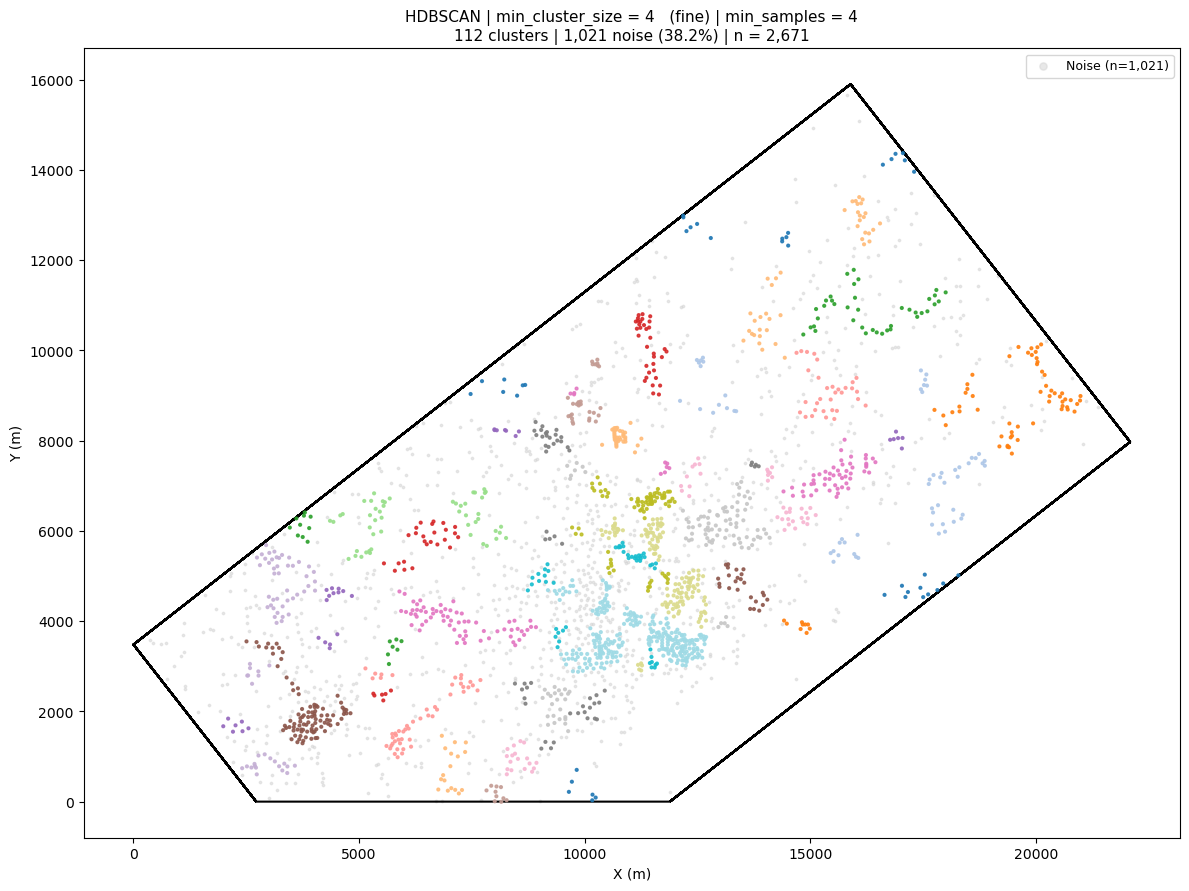

Saved: hdbscan_clustermap_4.png


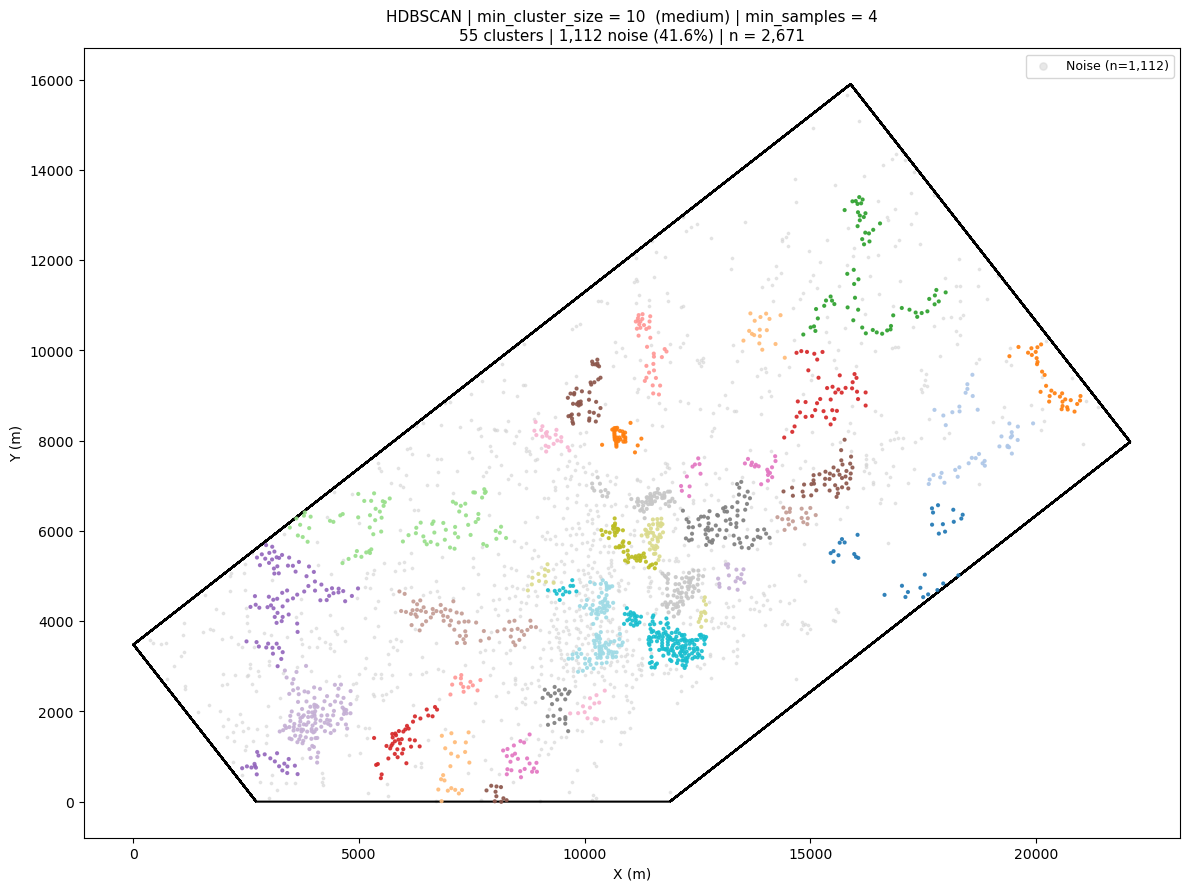

Saved: hdbscan_clustermap_10.png


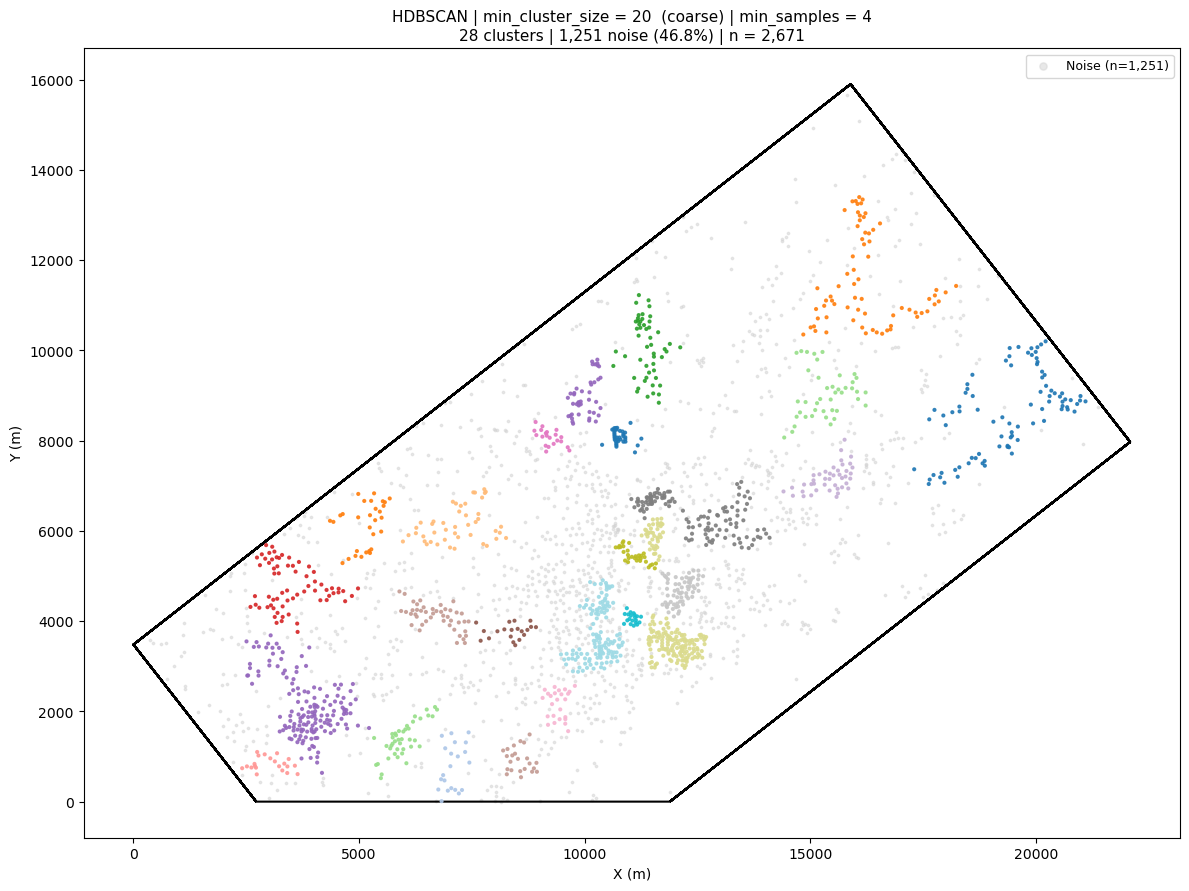

Saved: hdbscan_clustermap_20.png


In [20]:
for mcs in MCS_VALUES:
    labels     = results[mcs]
    n_cl       = len(set(labels)) - (1 if -1 in labels else 0)
    n_no       = (labels == -1).sum()
    noise_mask = labels == -1
    cl_mask    = ~noise_mask

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.scatter(x[noise_mask], y[noise_mask], s=3, c='lightgrey', alpha=0.5,
               label=f'Noise (n={n_no:,})', zorder=2)
    if cl_mask.sum() > 0:
        ax.scatter(x[cl_mask], y[cl_mask], s=4, c=labels[cl_mask],
                   cmap='tab20', alpha=0.85, zorder=3)
    parcel.boundary.plot(ax=ax, color='black', linewidth=1.5)
    ax.set_title(
        f'HDBSCAN | {MCS_LABELS[mcs]} | min_samples = {MIN_SAMPLES}\n'
        f'{n_cl} clusters | {n_no:,} noise ({100*n_no/len(labels):.1f}%) | n = {len(labels):,}',
        fontsize=11
    )
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=9, markerscale=3)
    plt.tight_layout()
    plt.savefig(f'/Users/amber/Documents/M Thesis/Notebooks/hdbscan_clustermap_{mcs}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: hdbscan_clustermap_{mcs}.png')

---
## 6. Cluster maps - side-by-side comparison

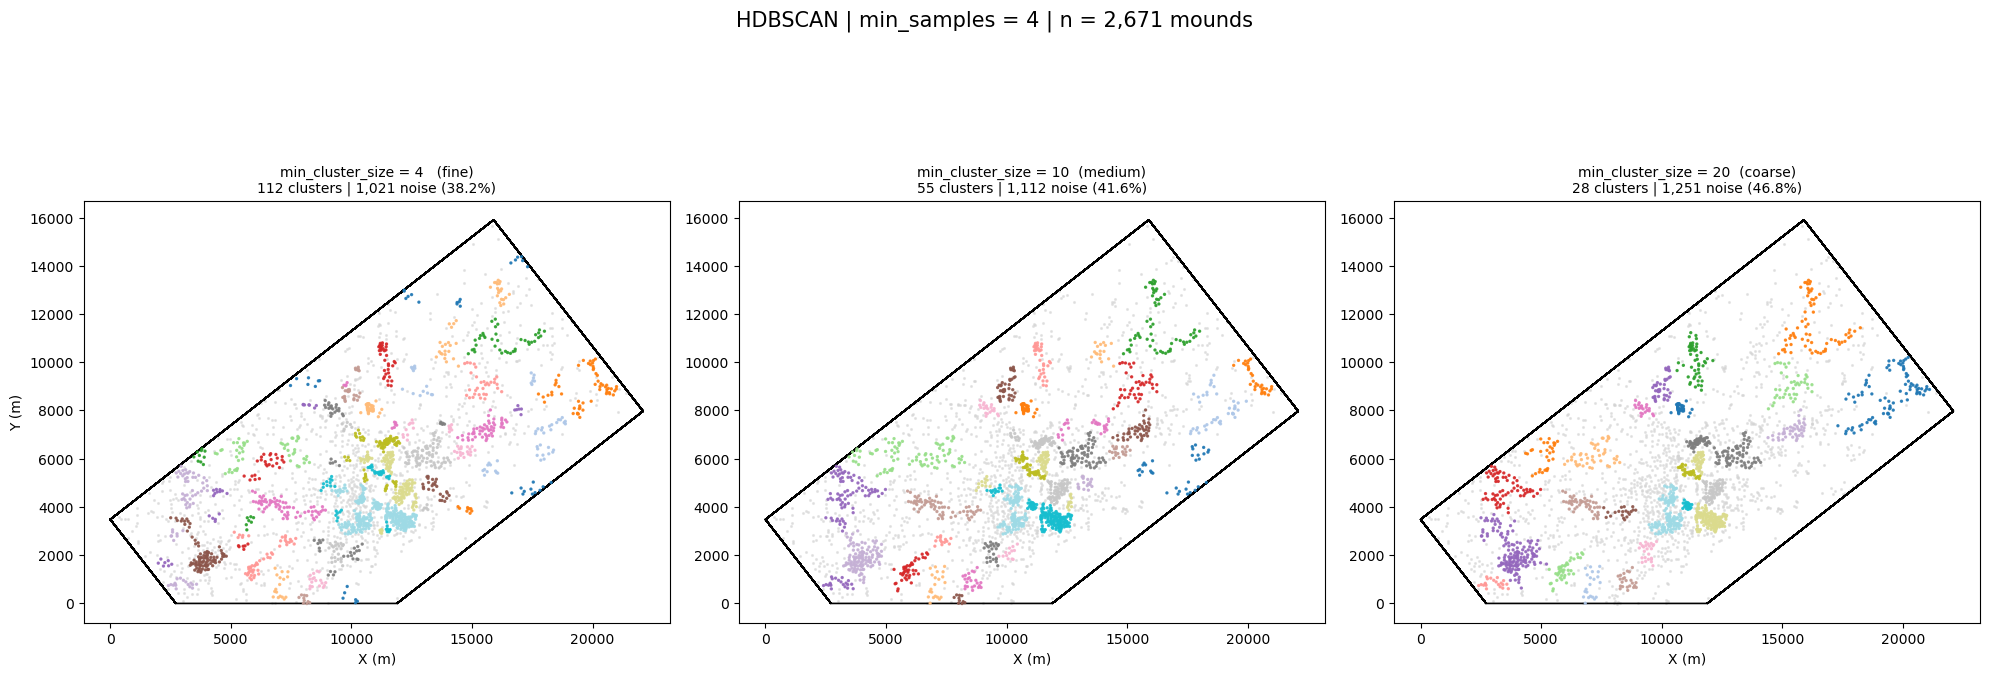

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, mcs in zip(axes, MCS_VALUES):
    labels     = results[mcs]
    n_cl       = len(set(labels)) - (1 if -1 in labels else 0)
    n_no       = (labels == -1).sum()
    noise_mask = labels == -1
    cl_mask    = ~noise_mask

    ax.scatter(x[noise_mask], y[noise_mask], s=1.5, c='lightgrey', alpha=0.5, zorder=2)
    if cl_mask.sum() > 0:
        ax.scatter(x[cl_mask], y[cl_mask], s=2, c=labels[cl_mask], cmap='tab20', alpha=0.85, zorder=3)
    parcel.boundary.plot(ax=ax, color='black', linewidth=1.2)
    ax.set_title(f'{MCS_LABELS[mcs]}\n{n_cl} clusters | {n_no:,} noise ({100*n_no/len(labels):.1f}%)', fontsize=10)
    ax.set_xlabel('X (m)')
    if ax == axes[0]:
        ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')

fig.suptitle(f'HDBSCAN | min_samples = {MIN_SAMPLES} | n = {len(coords):,} mounds', fontsize=15)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/hdbscan_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Condensed cluster tree

The condensed tree is the key diagnostic plot for HDBSCAN. It shows how clusters form and dissolve as the density threshold decreases (i.e., as lambda = 1/epsilon increases). Each horizontal band represents a cluster; its vertical extent encodes persistence (the range of densities over which the cluster survives). 

Note: at `min_cluster_size = 4` the tree is dense and harder to read due to the high cluster count. The pattern is clearer at larger `min_cluster_size` values.

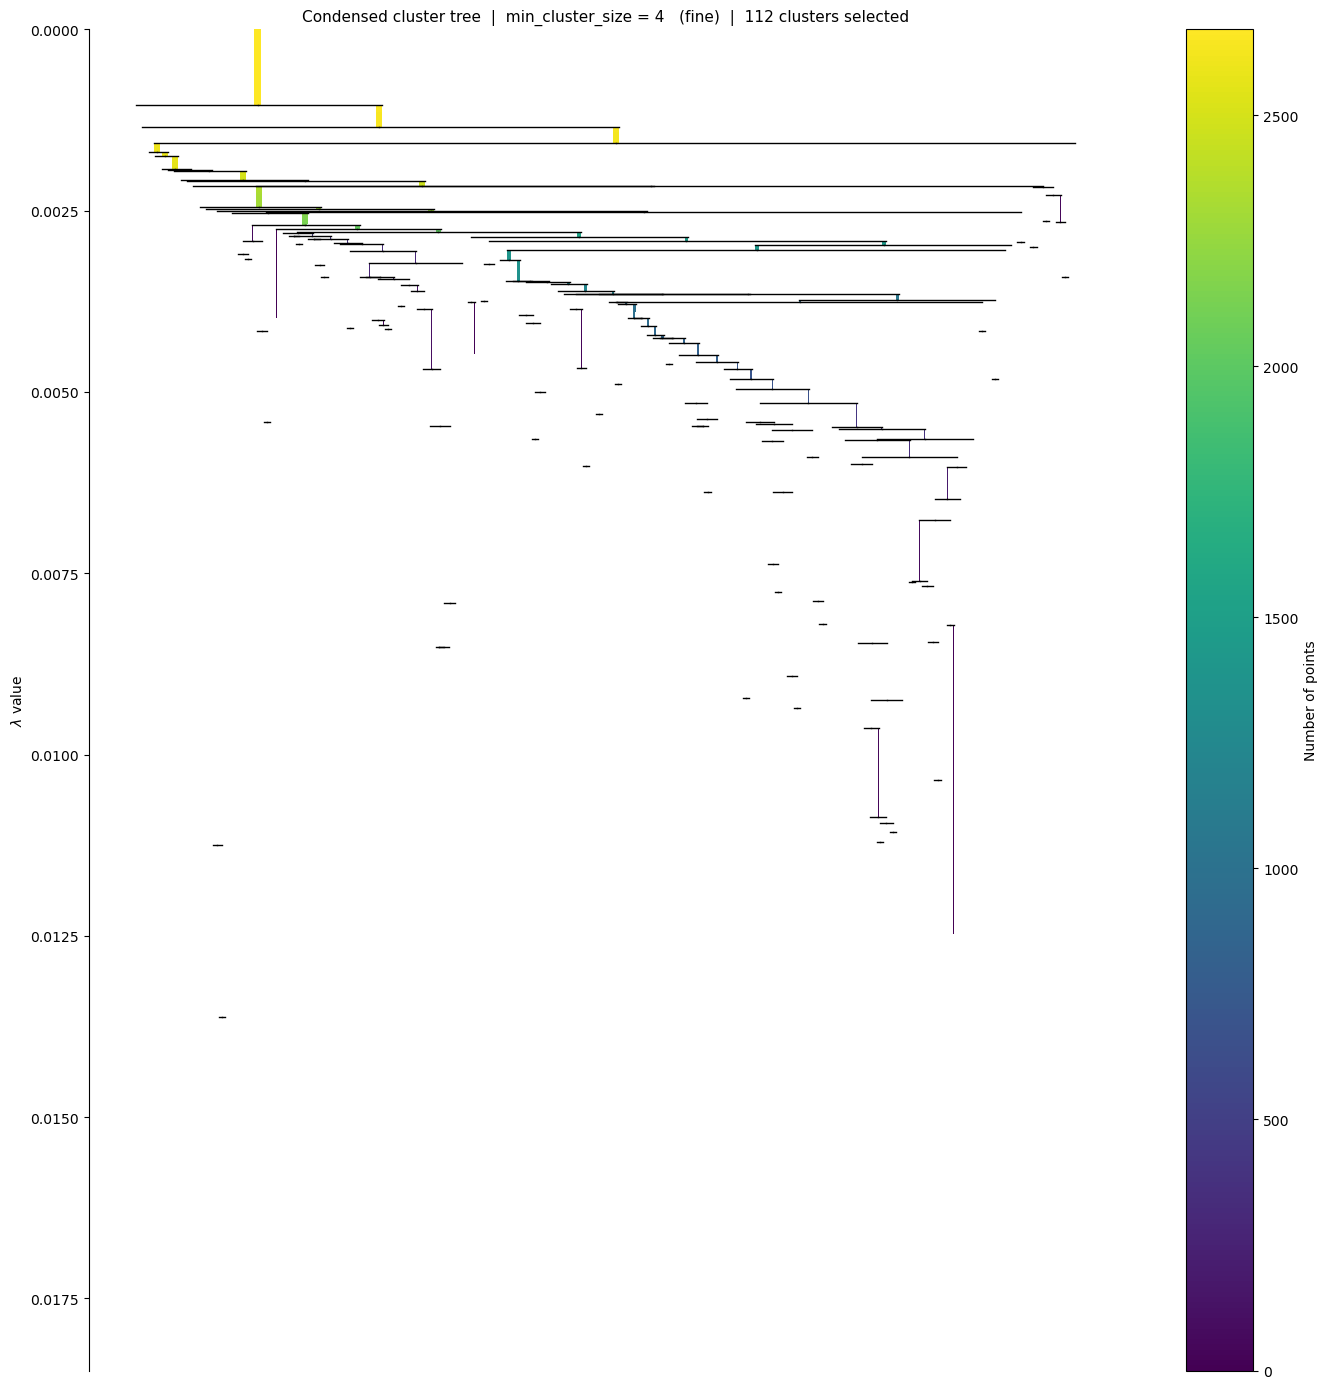

Saved: hdbscan_condensed_tree_4.png


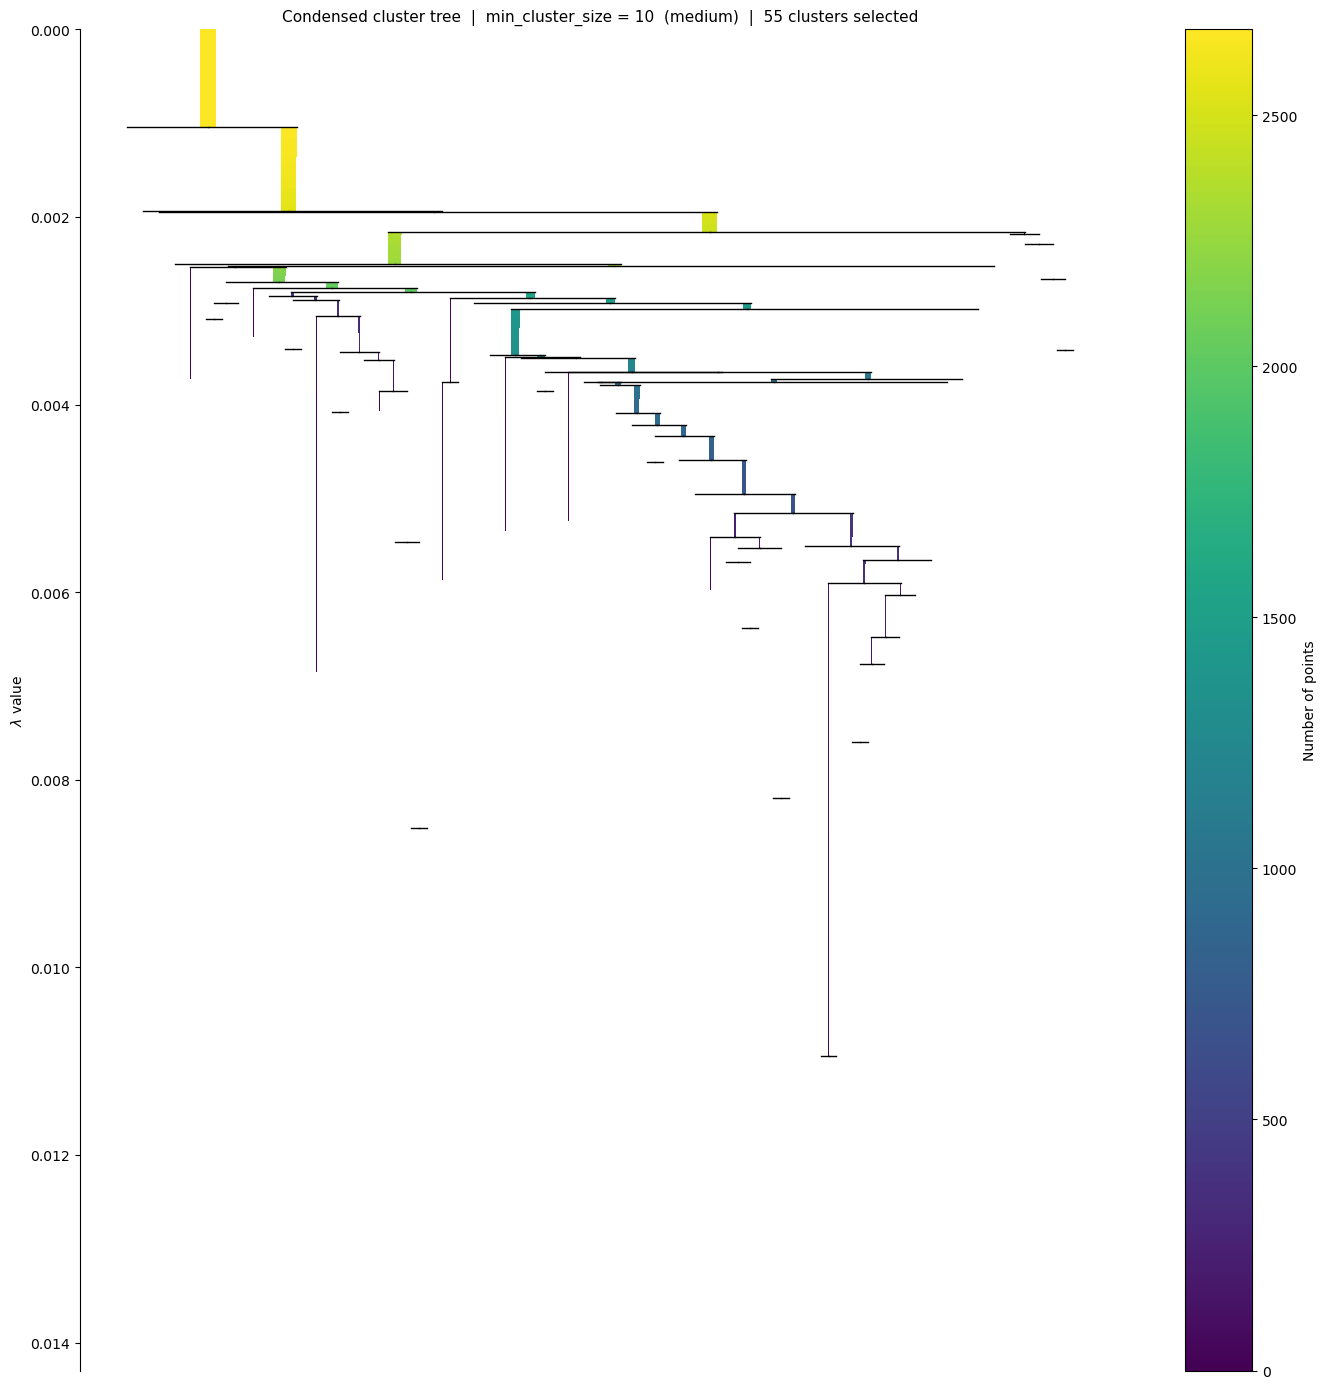

Saved: hdbscan_condensed_tree_10.png


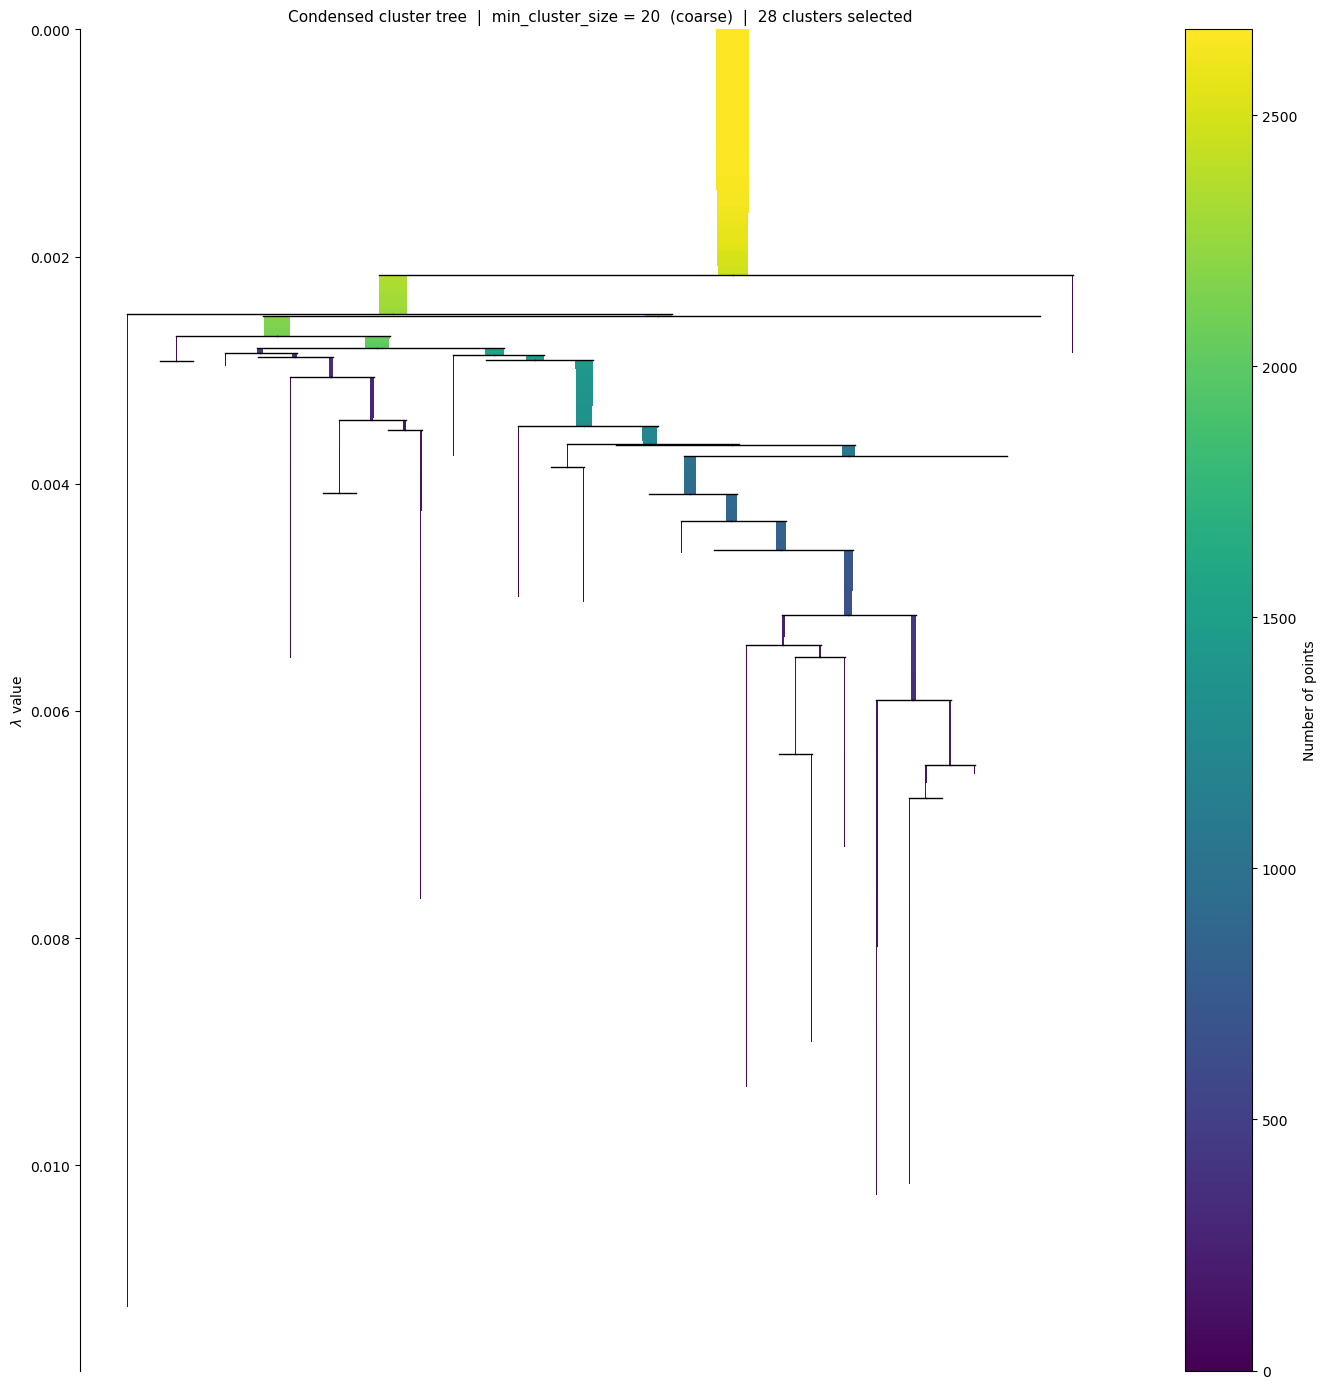

Saved: hdbscan_condensed_tree_20.png


In [24]:
## 7. Condensed cluster trees

for mcs in MCS_VALUES:
    cl   = clusterers[mcs]
    n_cl = len(set(results[mcs])) - (1 if -1 in results[mcs] else 0)

    fig, ax = plt.subplots(figsize=(14, 14))

    # select_clusters=False avoids a matplotlib >=3.8 Ellipse rendering bug
    cl.condensed_tree_.plot(select_clusters=False, label_clusters=True, axis=ax)

    ax.set_title(
        f'Condensed cluster tree  |  {MCS_LABELS[mcs]}  |  {n_cl} clusters selected',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(
        f'/Users/amber/Documents/M Thesis/Notebooks/hdbscan_condensed_tree_{mcs}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f'Saved: hdbscan_condensed_tree_{mcs}.png')

In [41]:
tree_df = clusterers[10].condensed_tree_.to_pandas()
cluster_tree = tree_df[tree_df.child_size > 1]
print(cluster_tree.sort_values('lambda_val', ascending=False).head(10))

      parent  child  lambda_val  child_size
2686    2780   2791    0.010940          19
2685    2780   2790    0.010940          11
1515    2731   2736    0.008512          16
1516    2731   2737    0.008512          10
2381    2769   2779    0.008194          11
2380    2769   2778    0.008194          15
2675    2786   2789    0.007602          46
2674    2786   2788    0.007602          17
2592    2784   2787    0.006763          45
2591    2784   2786    0.006763          83


In [42]:
tree_df = clusterers[10].condensed_tree_.to_pandas()
cluster_tree = tree_df[tree_df.child_size > 1]
print(cluster_tree.sort_values('lambda_val', ascending=False))

      parent  child  lambda_val  child_size
2686    2780   2791    0.010940          19
2685    2780   2790    0.010940          11
1515    2731   2736    0.008512          16
1516    2731   2737    0.008512          10
2381    2769   2779    0.008194          11
...      ...    ...         ...         ...
153     2675   2676    0.001951          11
137     2673   2675    0.001935        2526
136     2673   2674    0.001935          11
7       2671   2673    0.001041        2654
6       2671   2672    0.001041          11

[120 rows x 4 columns]


---
## 8. Cluster persistence

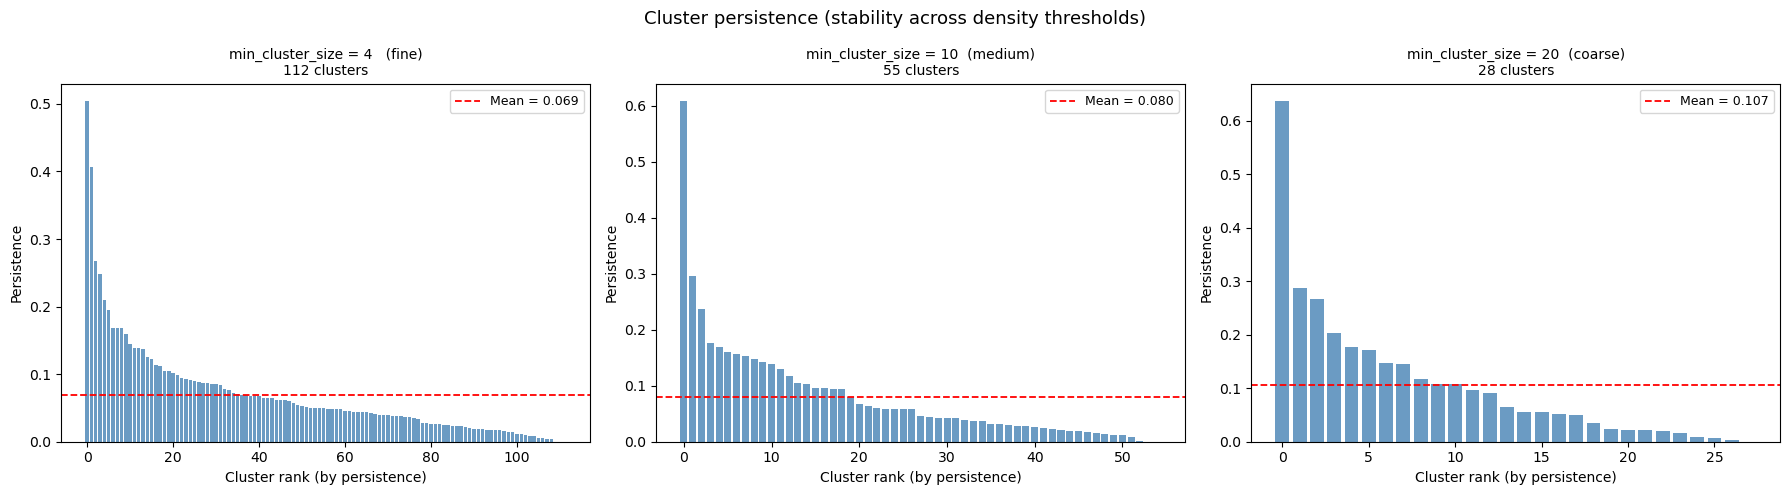

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, mcs in zip(axes, MCS_VALUES):
    cl   = clusterers[mcs]
    n_cl = len(set(results[mcs])) - (1 if -1 in results[mcs] else 0)

    if n_cl > 0 and hasattr(cl, 'cluster_persistence_'):
        persistence = np.sort(cl.cluster_persistence_)[::-1]
        ax.bar(range(len(persistence)), persistence, color='steelblue', alpha=0.8, edgecolor='none')
        ax.axhline(persistence.mean(), color='red', linestyle='--', linewidth=1.3,
                   label=f'Mean = {persistence.mean():.3f}')
        ax.legend(fontsize=9)
        ax.set_xlabel('Cluster rank (by persistence)')
        ax.set_ylabel('Persistence')
    else:
        ax.text(0.5, 0.5, 'No persistence data', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(f'{MCS_LABELS[mcs]}\n{n_cl} clusters', fontsize=10)

fig.suptitle('Cluster persistence (stability across density thresholds)', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/hdbscan_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Soft clustering - membership probabilities

HDBSCAN assigns each point a membership probability between 0 and 1, reflecting how confidently it belongs to its assigned cluster. Points near cluster cores score close to 1; borderline and noise-adjacent points score lower. This is not available in DBSCAN and provides a more nuanced picture of cluster membership.

Two maps are produced per scale: one coloured by cluster label (hard assignment) and one coloured by membership strength.

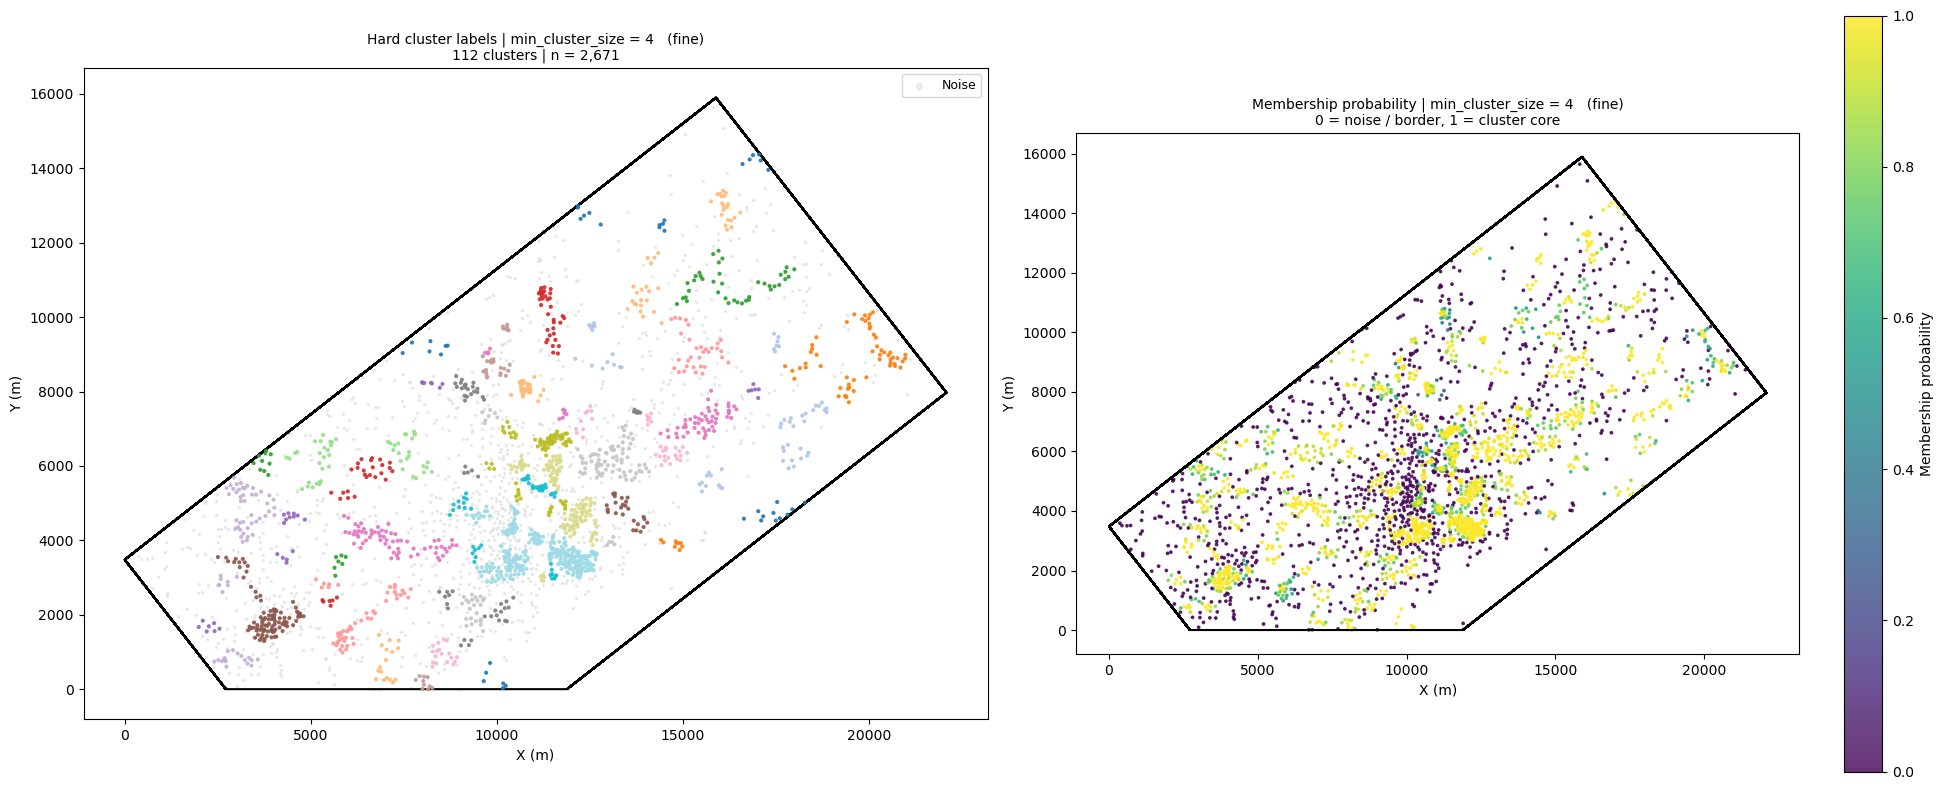

mcs = 4 | mean prob (clustered): 0.922 | mean prob (noise): 0.000


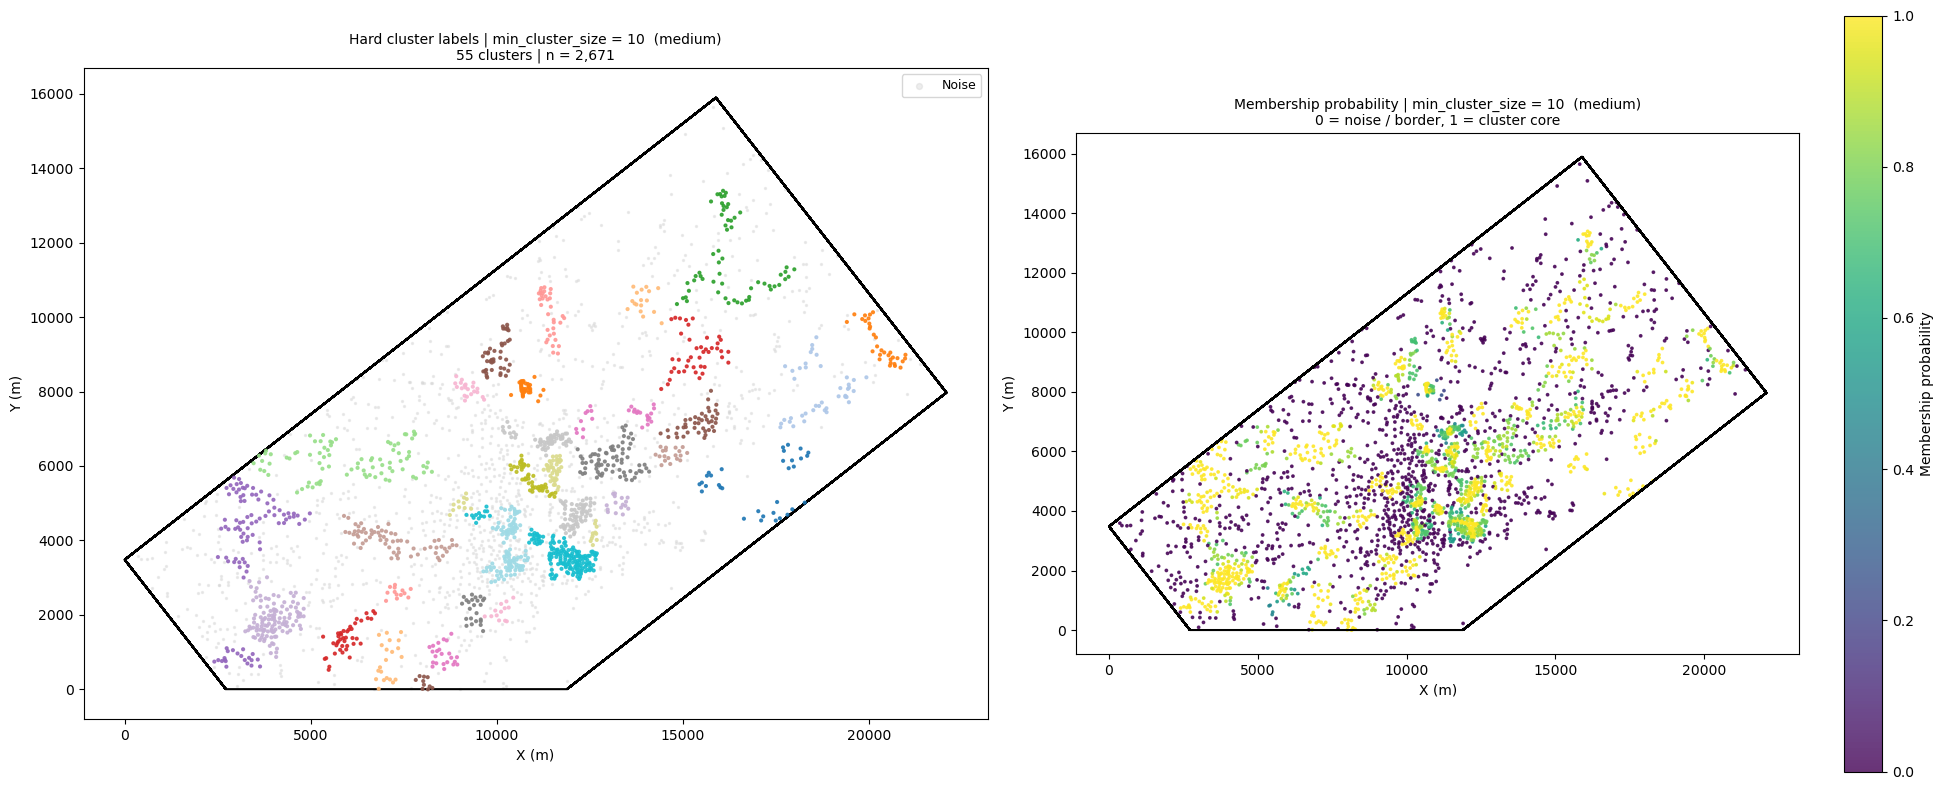

mcs = 10 | mean prob (clustered): 0.904 | mean prob (noise): 0.000


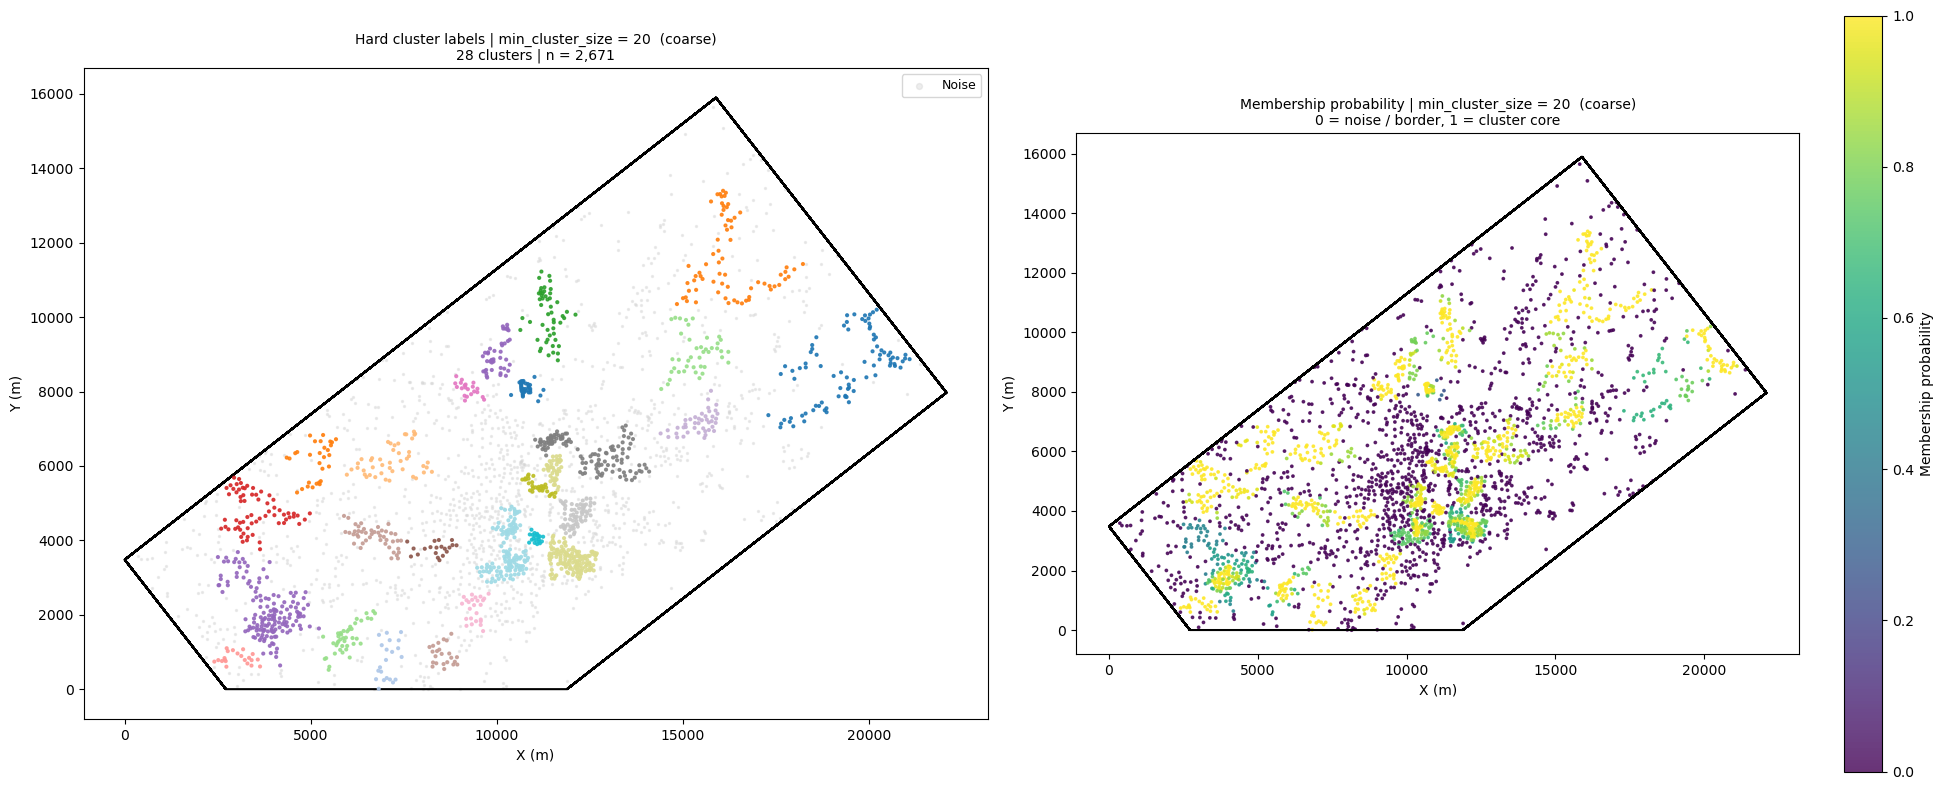

mcs = 20 | mean prob (clustered): 0.893 | mean prob (noise): 0.000


In [44]:
for mcs in MCS_VALUES:
    cl         = clusterers[mcs]
    labels     = results[mcs]
    probs      = cl.probabilities_
    n_cl       = len(set(labels)) - (1 if -1 in labels else 0)
    noise_mask = labels == -1
    cl_mask    = ~noise_mask

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Left: hard cluster assignment
    ax1.scatter(x[noise_mask], y[noise_mask], s=2, c='lightgrey', alpha=0.4, zorder=2, label='Noise')
    if cl_mask.sum() > 0:
        ax1.scatter(x[cl_mask], y[cl_mask], s=4, c=labels[cl_mask],
                    cmap='tab20', alpha=0.85, zorder=3)
    parcel.boundary.plot(ax=ax1, color='black', linewidth=1.5)
    ax1.set_title(f'Hard cluster labels | {MCS_LABELS[mcs]}\n{n_cl} clusters | n = {len(labels):,}', fontsize=10)
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Y (m)')
    ax1.set_aspect('equal')
    ax1.legend(loc='upper right', fontsize=9, markerscale=3)

    # Right: membership probability
    sc = ax2.scatter(x, y, s=3, c=probs, cmap='viridis', vmin=0, vmax=1, alpha=0.8, zorder=2)
    parcel.boundary.plot(ax=ax2, color='black', linewidth=1.5)
    plt.colorbar(sc, ax=ax2, label='Membership probability')
    ax2.set_title(f'Membership probability | {MCS_LABELS[mcs]}\n0 = noise / border, 1 = cluster core', fontsize=10)
    ax2.set_xlabel('X (m)')
    ax2.set_ylabel('Y (m)')
    ax2.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(f'/Users/amber/Documents/M Thesis/Notebooks/hdbscan_soft_{mcs}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"mcs = {mcs} | mean prob (clustered): {probs[cl_mask].mean():.3f} | mean prob (noise): {probs[noise_mask].mean():.3f}")

---
## 10. Noise analysis

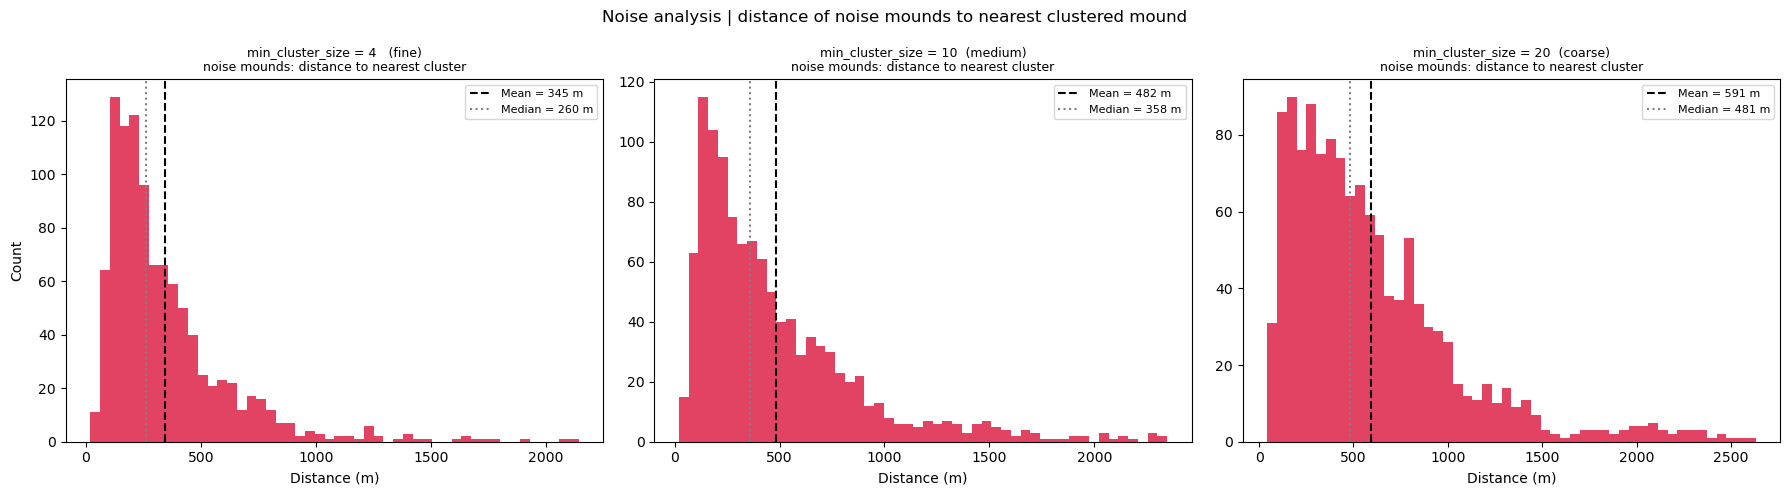

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, mcs in zip(axes, MCS_VALUES):
    labels     = results[mcs]
    noise_mask = labels == -1
    cl_mask    = ~noise_mask

    if noise_mask.sum() > 0 and cl_mask.sum() > 0:
        tree_cl = BallTree(coords[cl_mask], metric='euclidean')
        dist, _ = tree_cl.query(coords[noise_mask], k=1)
        dist    = dist.ravel()
        ax.hist(dist, bins=50, color='crimson', alpha=0.8, edgecolor='none')
        ax.axvline(dist.mean(),     color='black', linestyle='--', linewidth=1.5, label=f'Mean = {dist.mean():.0f} m')
        ax.axvline(np.median(dist), color='grey',  linestyle=':',  linewidth=1.5, label=f'Median = {np.median(dist):.0f} m')
        ax.legend(fontsize=8)
    elif noise_mask.sum() == 0:
        ax.text(0.5, 0.5, 'No noise points', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(f'{MCS_LABELS[mcs]}\nnoise mounds: distance to nearest cluster', fontsize=9)
    ax.set_xlabel('Distance (m)')
    if ax == axes[0]:
        ax.set_ylabel('Count')

fig.suptitle('Noise analysis | distance of noise mounds to nearest clustered mound', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/hdbscan_noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Cluster size distributions

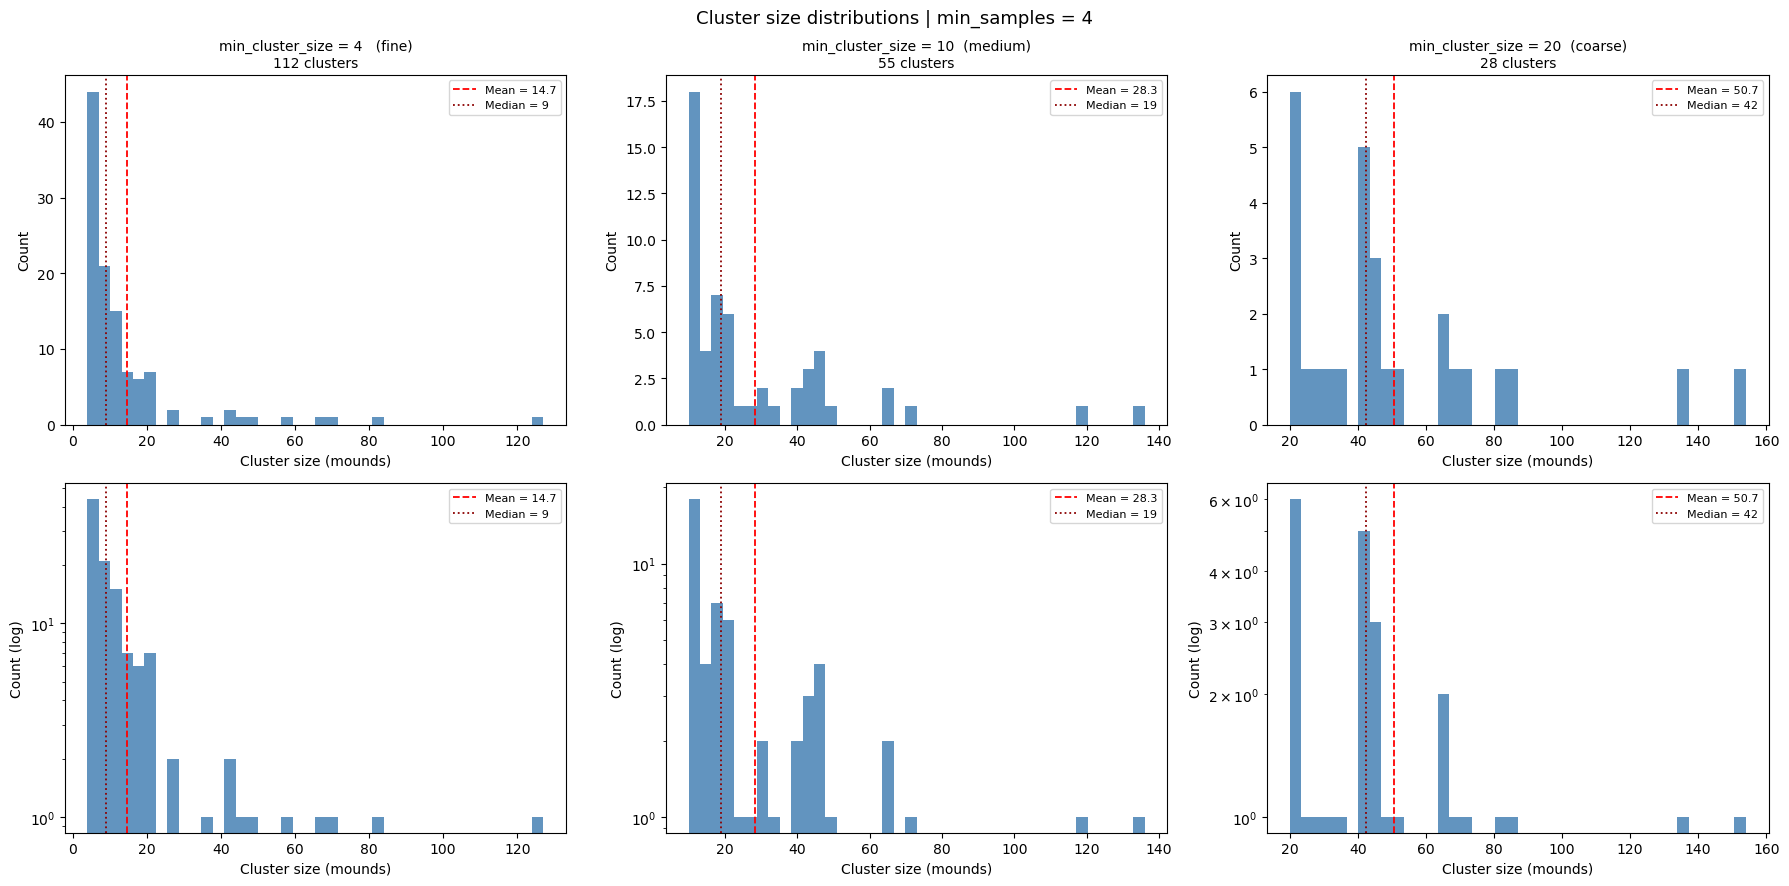

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col, mcs in enumerate(MCS_VALUES):
    labels   = results[mcs]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])

    for row, (yscale, ylabel) in enumerate([('linear', 'Count'), ('log', 'Count (log)')]):
        ax = axes[row][col]
        ax.hist(cl_sizes, bins=40, color='steelblue', alpha=0.85, edgecolor='none')
        ax.axvline(cl_sizes.mean(),     color='red',    linestyle='--', linewidth=1.3, label=f'Mean = {cl_sizes.mean():.1f}')
        ax.axvline(np.median(cl_sizes), color='darkred', linestyle=':',  linewidth=1.3, label=f'Median = {np.median(cl_sizes):.0f}')
        ax.set_yscale(yscale)
        ax.set_xlabel('Cluster size (mounds)')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        if row == 0:
            ax.set_title(f'{MCS_LABELS[mcs]}\n{len(cl_sizes)} clusters', fontsize=10)

fig.suptitle(f'Cluster size distributions | min_samples = {MIN_SAMPLES}', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/hdbscan_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Top clusters per scale

The 10 largest clusters at each `min_cluster_size`, annotated by rank.

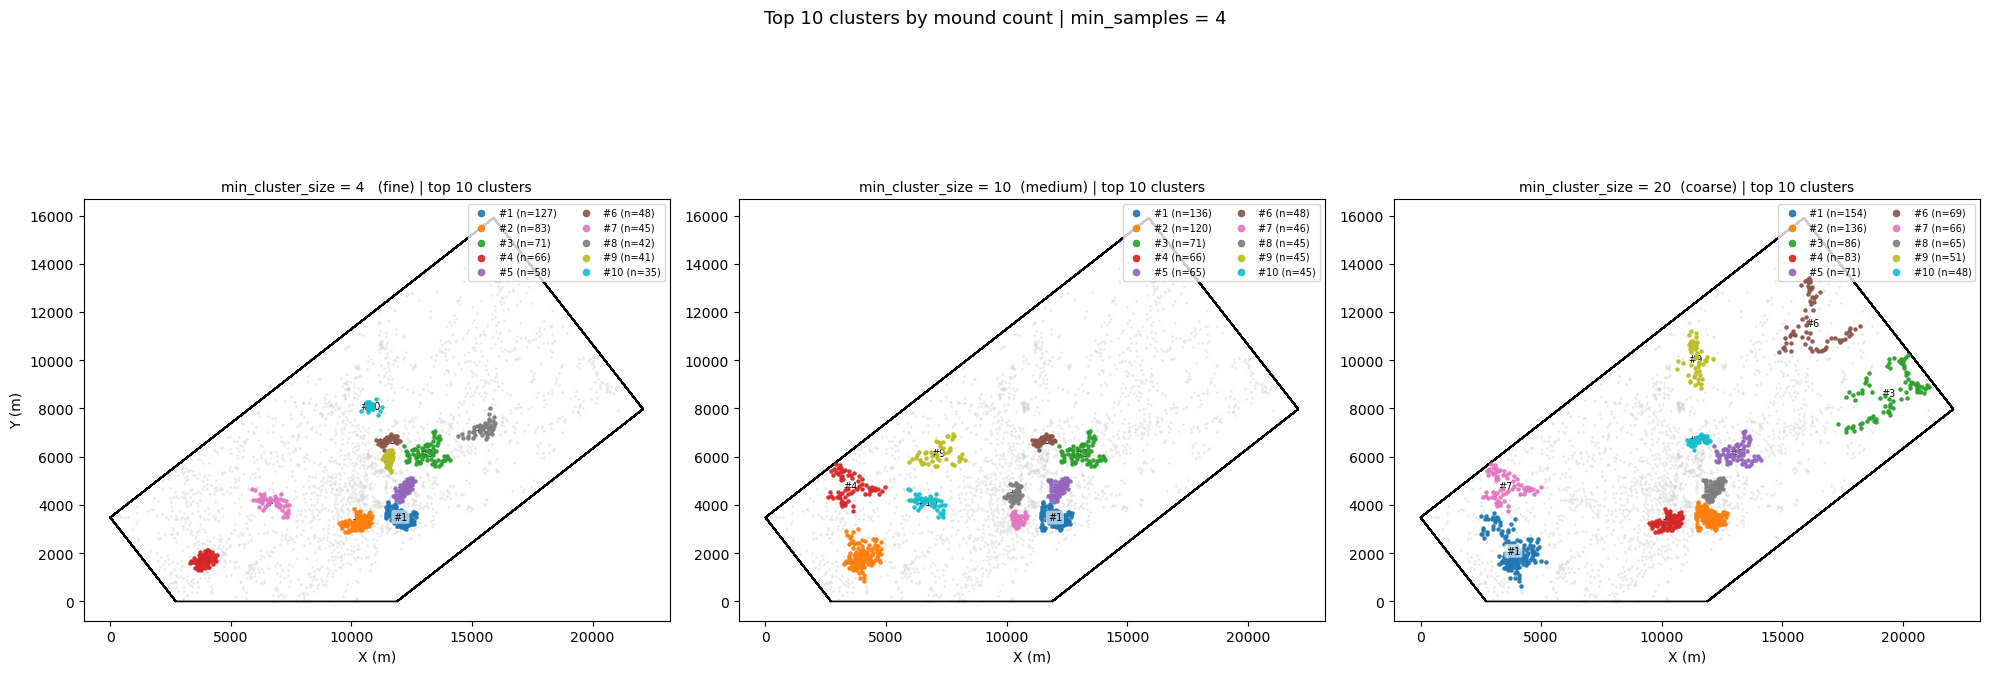

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
cmap_top  = plt.get_cmap('tab10')
top_n     = 10

for ax, mcs in zip(axes, MCS_VALUES):
    labels   = results[mcs]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])
    top_ids  = [cl_ids[i] for i in np.argsort(cl_sizes)[::-1][:top_n]]

    ax.scatter(x, y, s=1.5, c='lightgrey', alpha=0.3, zorder=1)

    for rank, cid in enumerate(top_ids):
        mask_c = labels == cid
        ax.scatter(x[mask_c], y[mask_c], s=5, color=cmap_top(rank / top_n),
                   alpha=0.9, label=f'#{rank+1} (n={mask_c.sum()})', zorder=3 + rank)
        cx, cy = x[mask_c].mean(), y[mask_c].mean()
        ax.annotate(f'#{rank+1}', (cx, cy), fontsize=7, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

    parcel.boundary.plot(ax=ax, color='black', linewidth=1.2)
    ax.set_title(f'{MCS_LABELS[mcs]} | top {top_n} clusters', fontsize=10)
    ax.set_xlabel('X (m)')
    if ax == axes[0]:
        ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=7, markerscale=2, ncol=2)

fig.suptitle(f'Top {top_n} clusters by mound count | min_samples = {MIN_SAMPLES}', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/hdbscan_top_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Summary statistics

In [48]:
for mcs in MCS_VALUES:
    labels   = results[mcs]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])
    n_no     = (labels == -1).sum()
    probs    = clusterers[mcs].probabilities_

    print(f"min_cluster_size = {mcs}")
    print(f"  clusters:           {len(cl_ids)}")
    print(f"  clustered:          {cl_sizes.sum():,} ({100*cl_sizes.sum()/len(labels):.1f}%)")
    print(f"  noise:              {n_no:,} ({100*n_no/len(labels):.1f}%)")
    print(f"  median size:        {np.median(cl_sizes):.0f} mounds")
    print(f"  largest cluster:    {cl_sizes.max()} mounds")
    print(f"  mean membership:    {probs[~(labels==-1)].mean():.3f}  (clustered points)")
    print()

min_cluster_size = 4
  clusters:           112
  clustered:          1,650 (61.8%)
  noise:              1,021 (38.2%)
  median size:        9 mounds
  largest cluster:    127 mounds
  mean membership:    0.922  (clustered points)

min_cluster_size = 10
  clusters:           55
  clustered:          1,559 (58.4%)
  noise:              1,112 (41.6%)
  median size:        19 mounds
  largest cluster:    136 mounds
  mean membership:    0.904  (clustered points)

min_cluster_size = 20
  clusters:           28
  clustered:          1,420 (53.2%)
  noise:              1,251 (46.8%)
  median size:        42 mounds
  largest cluster:    154 mounds
  mean membership:    0.893  (clustered points)



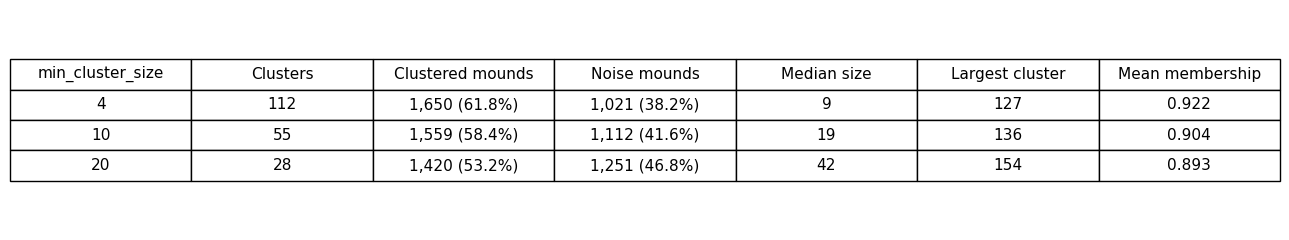

In [49]:
summary_rows = []
for mcs in MCS_VALUES:
    labels   = results[mcs]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])
    n_no     = (labels == -1).sum()
    probs    = clusterers[mcs].probabilities_
    summary_rows.append([
        str(mcs),
        str(len(cl_ids)),
        f'{cl_sizes.sum():,} ({100*cl_sizes.sum()/len(labels):.1f}%)',
        f'{n_no:,} ({100*n_no/len(labels):.1f}%)',
        f'{np.median(cl_sizes):.0f}',
        f'{cl_sizes.max()}',
        f'{probs[~(labels==-1)].mean():.3f}',
    ])

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.axis('off')
table = ax.table(
    cellText=summary_rows,
    colLabels=['min_cluster_size', 'Clusters', 'Clustered mounds', 'Noise mounds',
               'Median size', 'Largest cluster', 'Mean membership'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/hdbscan_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Per-cluster detail table - top 20 largest clusters across all scales
detail_rows = []
for mcs in MCS_VALUES:
    labels   = results[mcs]
    cl_ids   = [c for c in sorted(set(labels)) if c != -1]
    cl_sizes = np.array([(labels == c).sum() for c in cl_ids])
    probs    = clusterers[mcs].probabilities_
    for cid in [cl_ids[i] for i in np.argsort(cl_sizes)[::-1][:20]]:
        mask_c = labels == cid
        cx_m, cy_m = coords[mask_c, 0], coords[mask_c, 1]
        try:
            hull    = ConvexHull(coords[mask_c])
            area_km = hull.volume / 1e6
            dens    = mask_c.sum() / area_km
        except Exception:
            area_km, dens = np.nan, np.nan
        mean_prob = probs[mask_c].mean()
        detail_rows.append({
            'mcs': mcs,
            'Cluster': cid,
            'Mounds': mask_c.sum(),
            'Centroid X': f'{cx_m.mean():.0f}',
            'Centroid Y': f'{cy_m.mean():.0f}',
            'Hull area (km2)': f'{area_km:.2f}' if not np.isnan(area_km) else '--',
            'Density (mounds/km2)': f'{dens:.1f}' if not np.isnan(dens) else '--',
            'Mean membership': f'{mean_prob:.3f}',
        })

df_detail = pd.DataFrame(detail_rows)
print(df_detail.to_string(index=False))

 mcs  Cluster  Mounds Centroid X Centroid Y Hull area (km2) Density (mounds/km2) Mean membership
   4      106     127      12031       3506            0.93                137.1           0.971
   4      109      83      10282       3318            0.92                 90.1           0.989
   4       88      71      13104       6161            1.86                 38.2           0.980
   4       61      66       3882       1721            0.60                110.9           0.943
   4       95      58      12171       4637            0.49                118.3           0.954
   4       92      48      11511       6677            0.37                130.3           0.908
   4       72      45       6707       4100            1.11                 40.5           0.970
   4       70      42      15420       7159            1.03                 40.8           0.917
   4       97      41      11547       5897            0.26                157.6           0.938
   4       18      35      107